In [43]:
import numpy as np
import pandas as pd
import random
import missingno
from sklearn.linear_model import LogisticRegression
import sys
import math
import pickle
import shap
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../../Modules")
pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *
enc = 'utf-8'

In [44]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'

In [45]:
f = open(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_2008-2019_Cases_Dates.txt", "r")
print(f.read())

path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2008_2019.csv'

data = read_data(path)
data.head()

months: 6, 7, 8, 9, 10, 11, 
years: 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 


,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,11.79324,45.35865,2008-01-01,veneto,abano terme,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,19349,46.86670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.0,1.063084,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
1,12.04199,45.06525,2008-01-01,veneto,adria,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,20233,46.64640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6701.380530,1644.125334,2,145.603087,-1.354496,180.070371,0.0,1.206604,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
2,10.77673,45.55680,2008-01-01,veneto,affi,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,2297,46.81410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.0,1.815834,22.0,90.0,20.0,90.0,20.0,90.0,9,9.0,4.0,1.0,1.0,2,0,1,0,0
3,11.96539,45.17531,2008-01-01,veneto,agna,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,3400,46.73306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.0,3.769479,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,1,0,0
4,12.04755,46.30297,2008-01-01,veneto,agordo,1,1,1,2008,0.201299,0.97953,0.5,0.866025,0.118273,0.992981,4249,47.84463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.0,2.289867,15.0,92.0,10.0,91.0,10.0,91.0,5,5.0,7.0,1.0,1.0,2,0,1,0,0


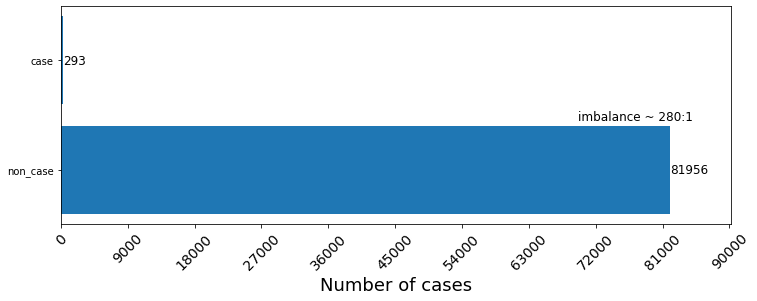

In [46]:
plot_imbalance(data.query('month >= 5 & month <= 10'))

In [47]:
dataset = data.query('month >= 6 & month <= 10')
dataset.reset_index(inplace=True, drop=True)
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,population,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,mosq_pred,mosq_previous,case
0,11.79324,45.35865,2008-06-01,veneto,abano terme,1,6,22,2008,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,19349,46.86670,0.401519,0.140618,-0.237628,-0.140618,0.346393,0.086866,-0.258230,-0.086866,0.056313,0.043306,0.015045,0.043306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8982.126981,2074.539971,3,170.409233,10.722186,179.966181,0.0,1.063084,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,326,367,0
1,12.04199,45.06525,2008-06-01,veneto,adria,1,6,22,2008,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,20233,46.64640,0.414457,0.179162,-0.238327,-0.179162,0.350741,0.114055,-0.246029,-0.114055,0.145941,0.160425,0.042403,0.160425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6701.380530,1644.125334,2,145.603087,-1.354496,180.070371,0.0,1.206604,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,371,447,0
2,10.77673,45.55680,2008-06-01,veneto,affi,1,6,22,2008,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,2297,46.81410,0.453163,0.214368,-0.218987,-0.214368,0.498889,0.203807,-0.264907,-0.203807,0.053675,0.050346,0.024386,0.050346,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5306.025387,738.794180,6,207.641691,201.821006,178.733735,0.0,1.815834,22.0,90.0,20.0,90.0,20.0,90.0,9,9.0,4.0,1.0,1.0,2,0,33,44,0
3,11.96539,45.17531,2008-06-01,veneto,agna,1,6,22,2008,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,3400,46.73306,0.330621,0.065681,-0.279323,-0.065681,0.332201,0.068339,-0.278148,-0.068339,0.065406,0.061280,0.013125,0.061280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16631.850238,1165.197945,3,121.193871,0.122498,180.188821,0.0,3.769479,31.0,99.0,36.0,99.0,30.0,99.0,12,12.0,1.0,6.0,7.0,2,0,314,541,0
4,12.04755,46.30297,2008-06-01,veneto,agordo,1,6,22,2008,0.201299,0.97953,1.224647e-16,-1.0,0.508531,-0.861044,4249,47.84463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15023.566702,684.464446,18,124.001040,1470.386475,152.701532,0.0,2.289867,15.0,92.0,10.0,91.0,10.0,91.0,5,5.0,7.0,1.0,1.0,2,0,28,41,0


In [48]:
dataset.columns

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'population', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop1_assessment', 'lc_prop2',
       'lc_prop2_assessment', 'lc_prop3', 'lc_prop3_assessment', 'lc_type1',
       'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'lw', 'qc

In [49]:
print(f'LAU1 Units: {dataset.lau1.unique().shape[0]}')

LAU1 Units: 571


In [50]:
dsc = dataframe_describe(dataset)
dsc.head(15)

,year,non-case,case,total,percentage
0,2008,5709,1,5710,8.33%
1,2009,5704,6,5710,8.33%
2,2010,5703,7,5710,8.33%
3,2011,5699,11,5710,8.33%
4,2012,5679,34,5713,8.33%
5,2013,5682,29,5711,8.33%
6,2014,5708,2,5710,8.33%
7,2015,5709,1,5710,8.33%
8,2016,5698,12,5710,8.33%
9,2017,5694,17,5711,8.33%


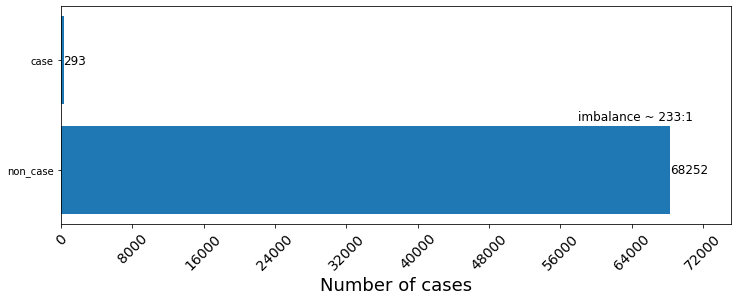

In [51]:
plot_imbalance(dataset)

In [52]:
majority_class = 0
near_u = 0.5
smote = 1
scaler = 'minmax'
weight_multiplier = 2
years_to_remove = [2014, 2015]
#years_to_remove = []

features_to_remove = ['day', 'month', 'week', 'year', 'day_sin', 'day_cos', 
                      'lc_prop1_assessment','lc_prop2_assessment','lc_prop3_assessment',
                      'lw', 'qc','lc_type1', 'lc_type3', 'lc_type4', 'lc_type5',]

#features_to_remove = []


In [53]:
dataset.select_dtypes(include=['object']).columns

Index(['dt_placement', 'nuts2', 'lau1'], dtype='object')

In [54]:
model_coefficients = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['case'] 
                                        + features_to_remove).columns

print(feature_names)

Index(['x', 'y', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'population', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2',
       'mosq_pred', 'mosq_previous'],
      dtype='object')


In [55]:
for train_idx, test_idx in yearCV_split(dataset, exclude_years_train=years_to_remove):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, scaler, majority_class, features_to_remove)
        
    w0,w1 = calculate_weights_new(y_train, weight_multiplier)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model, model_shap = train_lin_model(model, X_train, y_train, explain=True)

    train, test, coef = predict_lin_model_new(trained_model, X_train, y_train, X_test, y_test, data_test)
    
    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_coefficients.append(coef)
    model_shaps.append(model_shap)

    print(f"Year: {test['year'].iloc[0]} || w0:{w0}, w1:{w1} || ##")

shap_values= np.concatenate(model_shaps, axis=0)

Year: 2008 || w0:1, w1:90 || ##
Year: 2009 || w0:1, w1:92 || ##
Year: 2010 || w0:1, w1:92 || ##
Year: 2011 || w0:1, w1:92 || ##
Year: 2012 || w0:1, w1:100 || ##
Year: 2013 || w0:1, w1:98 || ##
Year: 2014 || w0:1, w1:98 || ##
Year: 2015 || w0:1, w1:98 || ##
Year: 2016 || w0:1, w1:92 || ##
Year: 2017 || w0:1, w1:94 || ##
Year: 2018 || w0:1, w1:168 || ##
Year: 2019 || w0:1, w1:102 || ##


In [56]:
feature_names

Index(['x', 'y', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'population', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi',
       'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std',
       'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
       'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week',
       'acc_rainfall_2week', 'acc_rainfall_jan', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2',
       'mosq_pred', 'mosq_previous'],
      dtype='object')

In [57]:
len(feature_names)

48

In [58]:
indicies = ['ndvi', 'ndmi', 'ndwi', 'ndbi',
            'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
            'ndvi_std','ndmi_std', 'ndwi_std', 'ndbi_std',]

weather = ['lst', 'lst_day', 'lst_night',
               'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_feb_day_mean',
               'lst_feb_night_mean', 'lst_mar_day_mean', 'lst_mar_night_mean',
               'lst_apr_day_mean', 'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',]

demographic = ['population']

geomorphological = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
                    'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
                    'flow_accu_200m', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type2',]

spatiotemporal = ['x', 'y', 'month_sin', 'month_cos', 'week_sin', 'week_cos','eq_distance',]

entomological = ['mosq_pred', 'mosq_previous']

In [59]:
len(indicies+weather+demographic+geomorphological+spatiotemporal+entomological)

48

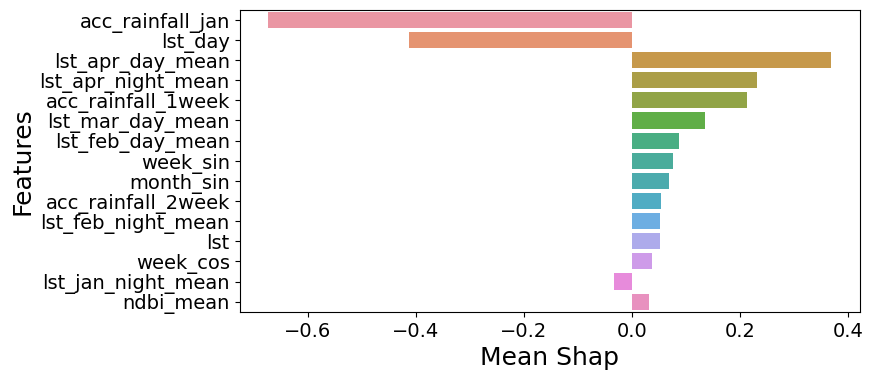

In [60]:
mean_shap = shap_values.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

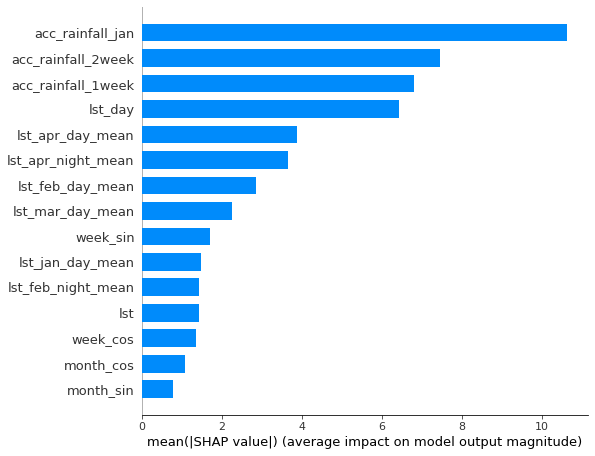

In [61]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

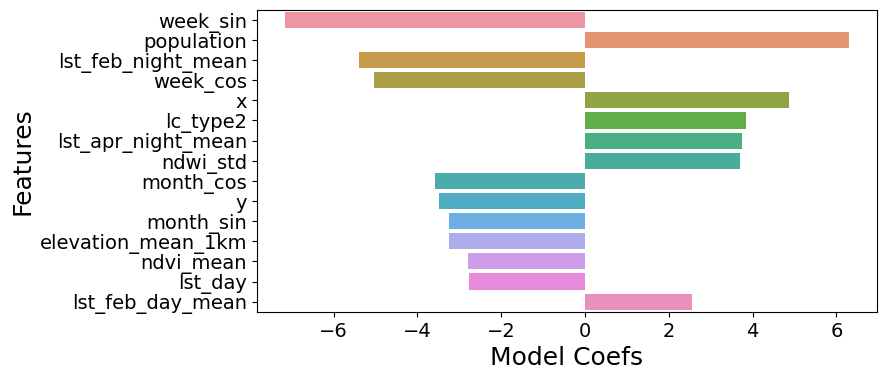

In [62]:
coefs = plot_feature_importance(model_coefficients, feature_names, x_label = 'Model Coefs', top = 15, figure_size = (8, 4))

In [63]:
coefs

,features,weights
4,week_sin,-7.162979
6,population,6.290770
26,lst_feb_night_mean,-5.384453
5,week_cos,-5.039037
0,x,4.860774
45,lc_type2,3.832679
30,lst_apr_night_mean,3.752889
18,ndwi_std,3.706324
3,month_cos,-3.590586
1,y,-3.489447


In [64]:
shaps

,features,weights,weights_abs
33,acc_rainfall_jan,-0.674421,0.674421
21,lst_day,-0.412713,0.412713
29,lst_apr_day_mean,0.368841,0.368841
30,lst_apr_night_mean,0.231923,0.231923
31,acc_rainfall_1week,0.213580,0.213580
27,lst_mar_day_mean,0.134942,0.134942
25,lst_feb_day_mean,0.086931,0.086931
4,week_sin,0.075221,0.075221
2,month_sin,0.068715,0.068715
32,acc_rainfall_2week,0.054018,0.054018


,features,weights
1,weather,0.169256
4,spatiotemporal,0.034168
3,geomorphological,0.005542
0,rs_indicies,0.005265
5,entomological,0.003642
2,demographic,0.002814


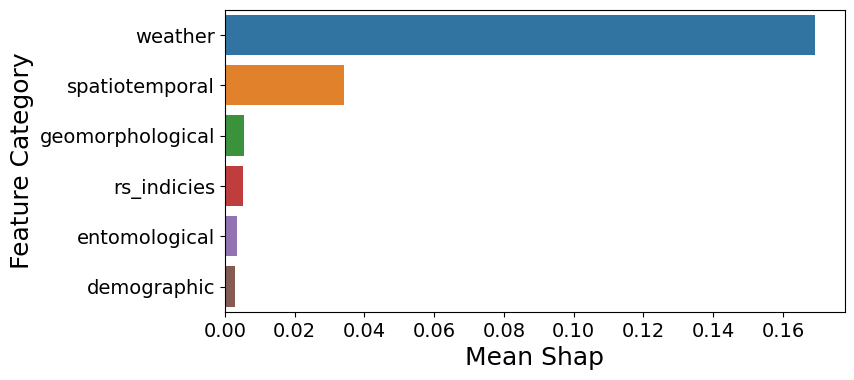

In [65]:
df_indicies = shaps.loc[shaps['features'].isin(indicies)].drop(columns=['weights'])
df_weather = shaps.loc[shaps['features'].isin(weather)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_geomorphological = shaps.loc[shaps['features'].isin(geomorphological)].drop(columns=['weights'])
df_spatiotemporal = shaps.loc[shaps['features'].isin(spatiotemporal)].drop(columns=['weights'])
df_entomological = shaps.loc[shaps['features'].isin(entomological)].drop(columns=['weights'])

categories = {'Category': ['rs_indicies', 'weather', 'demographic', 'geomorphological', 'spatiotemporal', 'entomological'], 
              'Mean_Shap': [df_indicies.weights_abs.mean(),df_weather.weights_abs.mean(),
                            df_demographic.weights_abs.mean(),df_geomorphological.weights_abs.mean(),
                            df_spatiotemporal.weights_abs.mean(),df_entomological.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,6)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

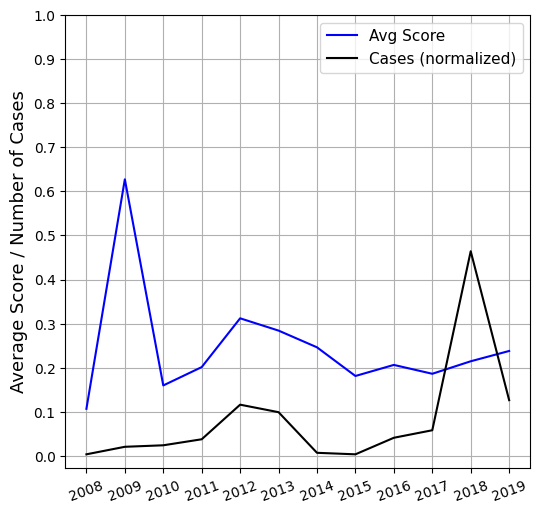

In [66]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']), x_label='', y_label='Average Score / Number of Cases', label_size = 13, tick_size=10, legend_size=11, figure_size = (6, 6) )

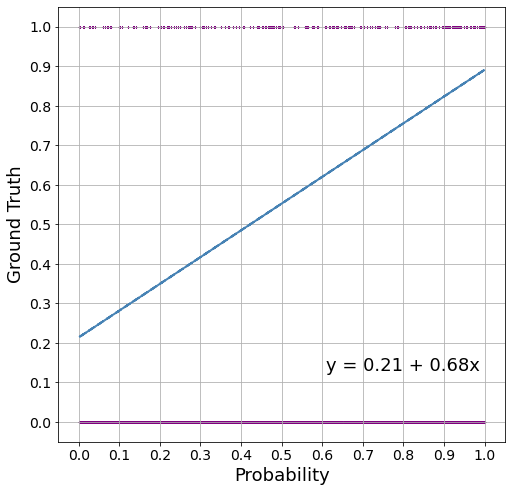

(0.2141719907448641, 0.6767735931463378)

In [67]:
plot_probability_curve(results_test)

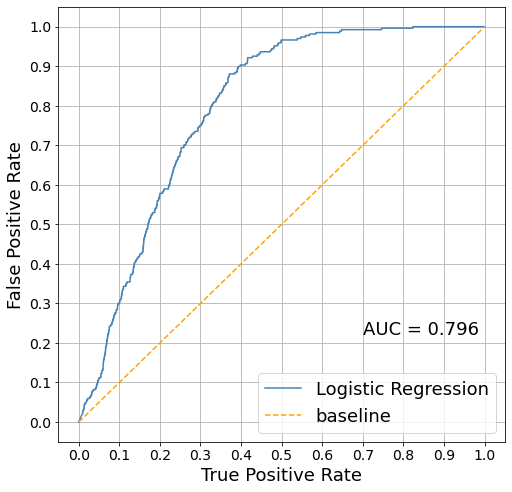

(0.3714, 0.8806, 0.1949, 0.744)

In [68]:
plot_roc_curve(results_test)

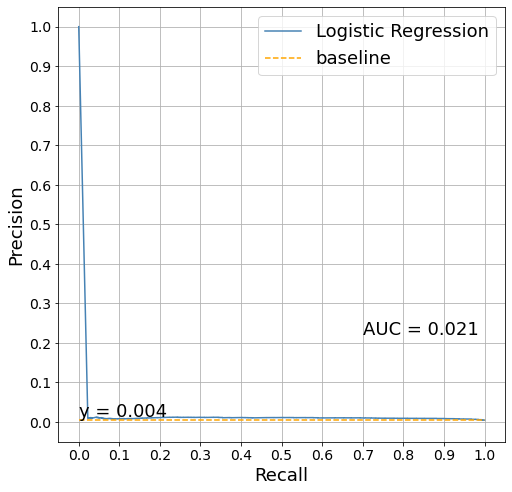

(0.3433, 0.01, 0.8, 0.053)

In [69]:
plot_pr_curve(results_test, plot_fbeta = False)

In [70]:
operational, cumulative, avg, weighted, r_avg, r_weighted = evaluate_operational(results_test, k = 100, ouput_random = True, sampling_number=100)
print(f'Average: {avg*100:.2f}%\nWeighted Average: {weighted*100:.2f}%')
print(f'\nRandom Average: {r_avg*100:.2f}%\nRandom Weighted Average: {r_weighted*100:.2f}%')

Average: 40.77%
Weighted Average: 38.06%

Random Average: 17.06%
Random Weighted Average: 17.65%


In [71]:
operational

,Prediction Date,Infected,Discovered,Random Discovered,Out of,Percentage,percentage,Random Percentage,random percentage
0,01/06/2008,0,0,0.00,0,NaN,NaN,NaN,NaN
1,16/06/2008,0,0,0.00,0,NaN,NaN,NaN,NaN
2,01/07/2008,0,0,0.00,0,NaN,NaN,NaN,NaN
3,16/07/2008,0,0,0.00,0,NaN,NaN,NaN,NaN
4,01/08/2008,0,0,0.00,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
115,16/08/2019,9,1,1.52,9,11.11 %,0.1111,16.89 %,0.1689
116,01/09/2019,11,4,1.78,11,36.36 %,0.3636,16.18 %,0.1618
117,16/09/2019,5,0,0.93,5,0.00 %,0.0000,18.60 %,0.1860
118,01/10/2019,1,1,0.19,1,100.00 %,1.0000,19.00 %,0.1900


In [72]:
cumulative

,Year,Infected,Discovered,Random Discovered,Out Of,Percentage,percentage,Random Percentage,random percentage
0,2008,1,1,0.14,1,100.00 %,1.0000,14.00 %,0.1400
1,2009,6,4,1.04,6,66.67 %,0.6667,17.33 %,0.1733
2,2010,7,5,1.15,7,71.43 %,0.7143,16.43 %,0.1643
3,2011,11,2,2.08,11,18.18 %,0.1818,18.91 %,0.1891
4,2012,31,20,5.56,31,64.52 %,0.6452,17.94 %,0.1794
5,2013,28,10,5.03,28,35.71 %,0.3571,17.96 %,0.1796
6,2014,2,0,0.34,2,0.00 %,0.0000,17.00 %,0.1700
7,2015,1,0,0.15,1,0.00 %,0.0000,15.00 %,0.1500
8,2016,12,4,2.19,12,33.33 %,0.3333,18.25 %,0.1825
9,2017,16,7,2.77,16,43.75 %,0.4375,17.31 %,0.1731


In [73]:
report_train, report_test = classification_report_new(results_train, results_test, threshold = 0.2, beta = 4)

In [74]:
report_train

,Accuracy,Precision,Recall,F4 Score,Loss
0,0.732,0.0349,0.987,0.3793,0.57


In [75]:
report_test.head(15)

,Year,Infected,Positive Rate,Accuracy,Precision,Recall,F4 Score,Loss
0,2008,1.0000,0.1951,0.9025,0.0009,1.0000,0.0150,0.1564
1,2009,6.0000,0.7499,0.6252,0.0014,1.0000,0.0233,2.3554
2,2010,7.0000,0.2753,0.6482,0.0025,0.5714,0.0404,0.2640
3,2011,11.0000,0.3250,0.8381,0.0059,1.0000,0.0920,0.3732
4,2012,31.0000,0.4592,0.7719,0.0118,1.0000,0.1690,0.6006
5,2013,28.0000,0.4299,0.7864,0.0114,1.0000,0.1640,0.5429
6,2014,2.0000,0.3673,0.8165,0.0010,1.0000,0.0160,0.5319
7,2015,1.0000,0.3116,0.8443,0.0006,1.0000,0.0095,0.3072
8,2016,12.0000,0.3601,0.8206,0.0058,1.0000,0.0907,0.3287
9,2017,16.0000,0.3194,0.8099,0.0082,0.9375,0.1226,0.3144


In [76]:
results_test

,lau1,day,month,year,case,score
0,ospitale da cadore,16,8,2019,0,1.000000e+00
1,mogliano veneto,1,7,2018,0,1.000000e+00
2,negrar,1,7,2018,0,1.000000e+00
3,nervesa da battaglia,1,7,2018,0,1.000000e+00
4,monticello conte otto,1,7,2018,0,1.000000e+00
...,...,...,...,...,...,...
68515,saint gregorio nelle alpi,1,9,2014,0,2.431792e-41
68516,ferrara da monte baldo,1,7,2014,0,1.457216e-42
68517,lamon,1,7,2014,0,3.552636e-43
68518,enego,1,7,2014,0,2.602595e-43


In [77]:
results_test[['lau1', 'day', 'month', 'year']].value_counts()

lau1         day  month  year
abano terme  1    6      2008    1
quero vas    16   8      2008    1
                  6      2018    1
                         2019    1
                  7      2008    1
                                ..
ficarolo     1    9      2018    1
                         2019    1
                  10     2008    1
                         2009    1
zugliano     16   10     2019    1
Length: 68520, dtype: int64

In [78]:
# results_test.to_csv(f"../../data/{NUTS2}/results/{NUTS0}_{NUTS2}_Results_2010-2022.csv", encoding = enc, index = False)

In [79]:
data_train = dataset.loc[~dataset['year'].isin(years_to_remove)]
data_train.reset_index(inplace = True, drop = True)

object_cols = data_train.select_dtypes(include=['object']).columns.to_list()
removed_cols = features_to_remove

X_train = data_train.drop(columns = ['case'] + object_cols + removed_cols)
y_train = data_train['case']

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
           
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)

y_train_value_counts = y_train.value_counts()
class_0_counts = y_train_value_counts.get(key = 0) if y_train_value_counts.get(key = 0) is not None else 0
class_1_counts = y_train_value_counts.get(key = 1) if y_train_value_counts.get(key = 1) is not None else 0
        
if (near_u != 0):
    if majority_class == 0:
        nm = NearMiss(sampling_strategy = {0: math.ceil(class_0_counts * (1 - near_u)), 1: class_1_counts}, version = 1, n_jobs = -1)
    elif majority_class == 1:
        nm = NearMiss(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 - near_u))}, version = 1, n_jobs = -1)

    X_train_resampled, y_train_resampled = nm.fit_resample(X_train_imputed, y_train)

    y_train_value_counts = y_train_resampled.value_counts()
    class_0_counts = y_train_value_counts.get(key = 0) if y_train_value_counts.get(key = 0) is not None else 0
    class_1_counts = y_train_value_counts.get(key = 1) if y_train_value_counts.get(key = 1) is not None else 0
        

if (smote != 0):
    if majority_class == 0:
        sm = BorderlineSMOTE(sampling_strategy = {0: class_0_counts, 1: math.ceil(class_1_counts * (1 + smote))}, n_jobs = -1, random_state = 0)
    elif majority_class == 1:
        sm = BorderlineSMOTE(sampling_strategy = {0: math.ceil(class_0_counts * (1 + smote)), 1: class_1_counts}, n_jobs = -1, random_state = 0)

    if (near_u != 0):
        X_train_resampled, y_train_resampled = sm.fit_resample(X_train_resampled, y_train_resampled)
    else:
        X_train_resampled, y_train_resampled = sm.fit_resample(X_train_imputed, y_train)

X_train_returned = X_train_imputed if (near_u == 0 and smote == 0) else X_train_resampled
y_train_returned = y_train if (near_u == 0 and smote == 0) else y_train_resampled

value_counts = y_train_returned.value_counts()
non_cases = value_counts.get(key = 0) if value_counts.get(key = 0) is not None else 0
cases = value_counts.get(key = 1) if value_counts.get(key = 1) is not None else 0
        
if non_cases >= cases:
    w0 = 1
    try:
        w1 = math.ceil(non_cases/cases)
    except ZeroDivisionError:
        w1 = 10
else:
    w1 = 1
    try:
        w0 = math.ceil(cases/non_cases)
    except ZeroDivisionError:
        w0 = 10
            
w1 = w1*weight_multiplier

model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

model.fit(X_train_returned, y_train_returned)

model


LogisticRegression(class_weight={0.0: 1, 1.0: 98}, max_iter=1000, n_jobs=-1,
                   random_state=0)

In [80]:
pickle.dump(model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Linear_model_new.pkl', 'wb'))
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Imputer_new.pkl', 'wb'))
pickle.dump(scaler, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Scaler_new.pkl', 'wb'))